## Importing Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Weather Data

**Column Details**

- `Month` : Month of data record
- `District` : Name of the district
- `RainFall` : Average Cumulative Rainfall in mm
- `Min_Temp` : Average Minimum Temperature in celcius
- `Max_Temp` : Average Maximum Temperature in celcius
- `Min_Humidity` : AverageMinimum Humidity %
- `Max_Humidity` : Average Maximum Humidity %

### 1.1 Basic Information

In [2]:
Weather_DF = pd.read_csv('Data/processed/Weather_Data_Processed.csv')
print('>>> Weather Data Head\n')
Weather_DF.head()

>>> Weather Data Head



,Month,District,RainFall,Min_Temp,Max_Temp,Min_Humidity,Max_Humidity
0,2019-01-01,Adilabad,0.130856,12.201262,29.281907,33.557363,83.543058
1,2019-01-01,Bhadradri Kothagudem,0.399778,16.166407,30.902670,45.012013,96.371079
2,2019-01-01,Hyderabad,0.942028,17.713180,30.756221,34.638618,81.040737
3,2019-01-01,Jagtial,0.735484,14.104624,29.920323,37.005914,92.996452
4,2019-01-01,Jangaon,0.837742,15.170161,29.263065,38.379839,89.622903


In [3]:
print('>>> Weather Data Info\n')
Weather_DF.info()

>>> Weather Data Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2333 entries, 0 to 2332
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Month         2333 non-null   object 
 1   District      2333 non-null   object 
 2   RainFall      2333 non-null   float64
 3   Min_Temp      2333 non-null   float64
 4   Max_Temp      2333 non-null   float64
 5   Min_Humidity  2333 non-null   float64
 6   Max_Humidity  2333 non-null   float64
dtypes: float64(5), object(2)
memory usage: 127.7+ KB


In [4]:
print('>>> Weather Data Descriptive statistics\n')
Weather_DF.describe()

>>> Weather Data Descriptive statistics



,RainFall,Min_Temp,Max_Temp,Min_Humidity,Max_Humidity
count,2333.000000,2333.000000,2333.000000,2333.000000,2333.000000
mean,3.155396,22.354275,33.321535,48.007126,89.341225
std,4.486925,4.089226,4.389334,17.073126,10.605450
min,0.000000,11.214286,13.190538,13.310714,36.029874
25%,0.091538,19.314259,31.205279,34.449167,85.263930
50%,0.967494,23.155054,32.766244,46.641944,93.773684
75%,5.113978,24.948148,36.489259,63.419916,96.573041
max,33.508602,33.856802,43.749247,83.868871,100.000000


### 1.2 Data Cleaning and Type Correction

In [5]:
# Convert 'Month' to datetime objects for time-series analysis
Weather_DF['Month'] = pd.to_datetime(Weather_DF['Month'])

### 1.3 Missing Values Check

In [6]:
print('>>> Missing Values in Data\n')
print(Weather_DF.isnull().sum())

>>> Missing Values in Data

Month           0
District        0
RainFall        0
Min_Temp        0
Max_Temp        0
Min_Humidity    0
Max_Humidity    0
dtype: int64


### 1.4 Unique Values and Cardinality

In [7]:
print(f'Unique # Districts in Weather Data :: {Weather_DF['District'].nunique()}')
print('>>> Top 5 districts by data points')
Weather_DF['District'].value_counts().head()

Unique # Districts in Weather Data :: 33
>>> Top 5 districts by data points


District
Adilabad                72
Bhadradri Kothagudem    72
Hyderabad               72
Jagtial                 72
Jangaon                 72
Name: count, dtype: int64

### 1.5 Distribution of Numerical Features

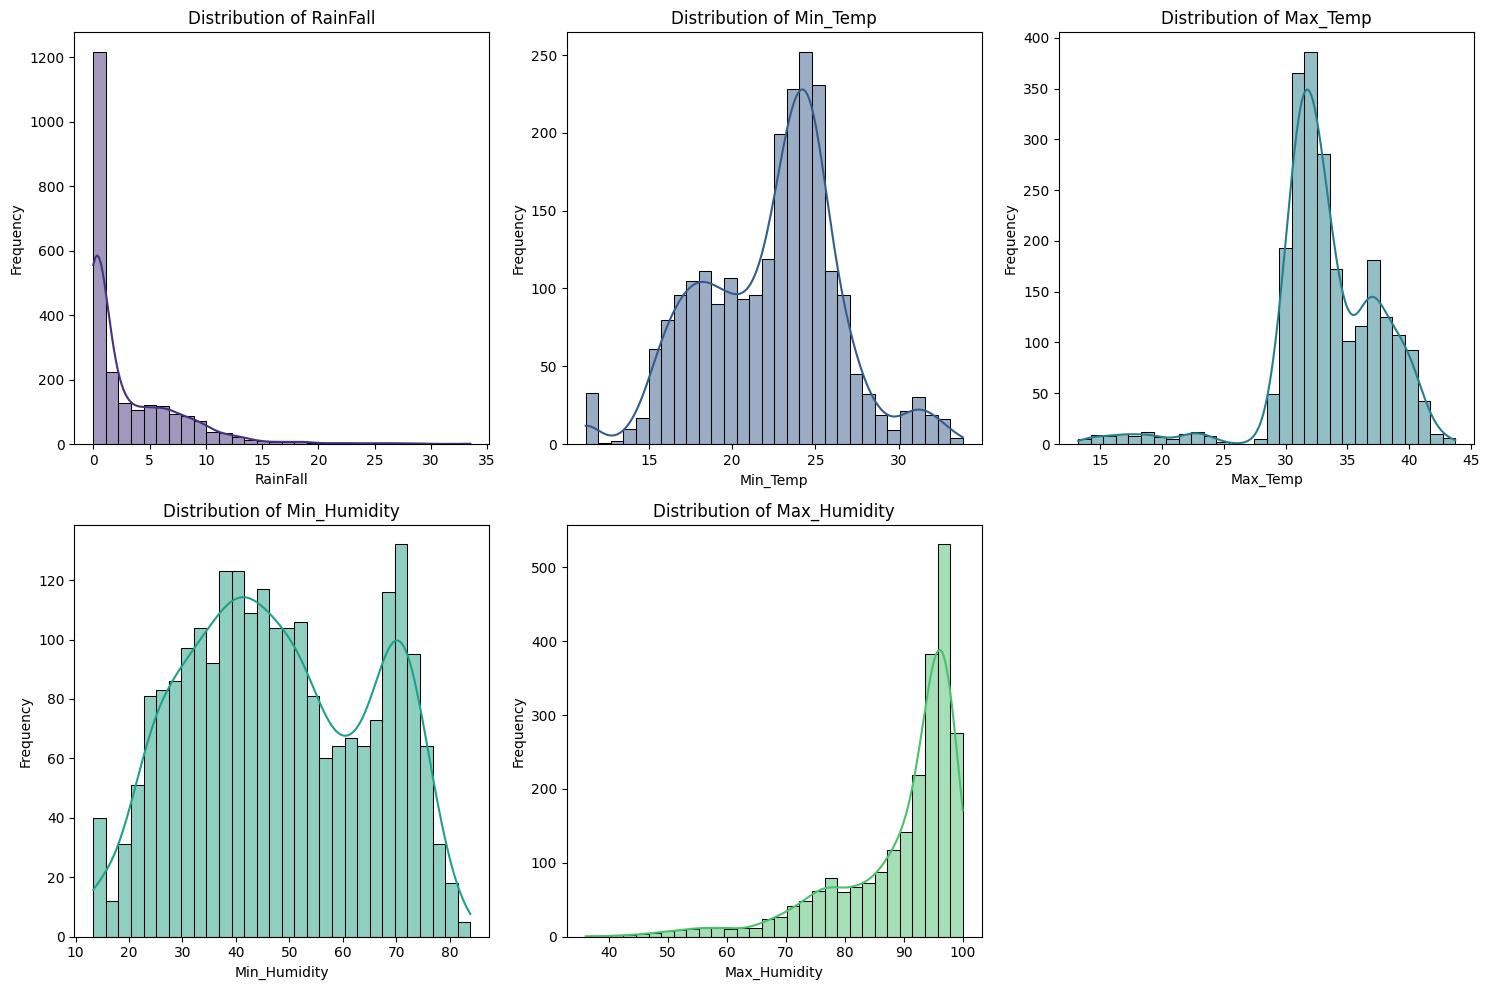

In [8]:
# Distribution Plots

numerical_cols = ['RainFall', 'Min_Temp', 'Max_Temp', 'Min_Humidity', 'Max_Humidity']

plt.figure(figsize = (15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(Weather_DF[col], kde = True, bins = 30, color = sns.color_palette("viridis")[i])
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

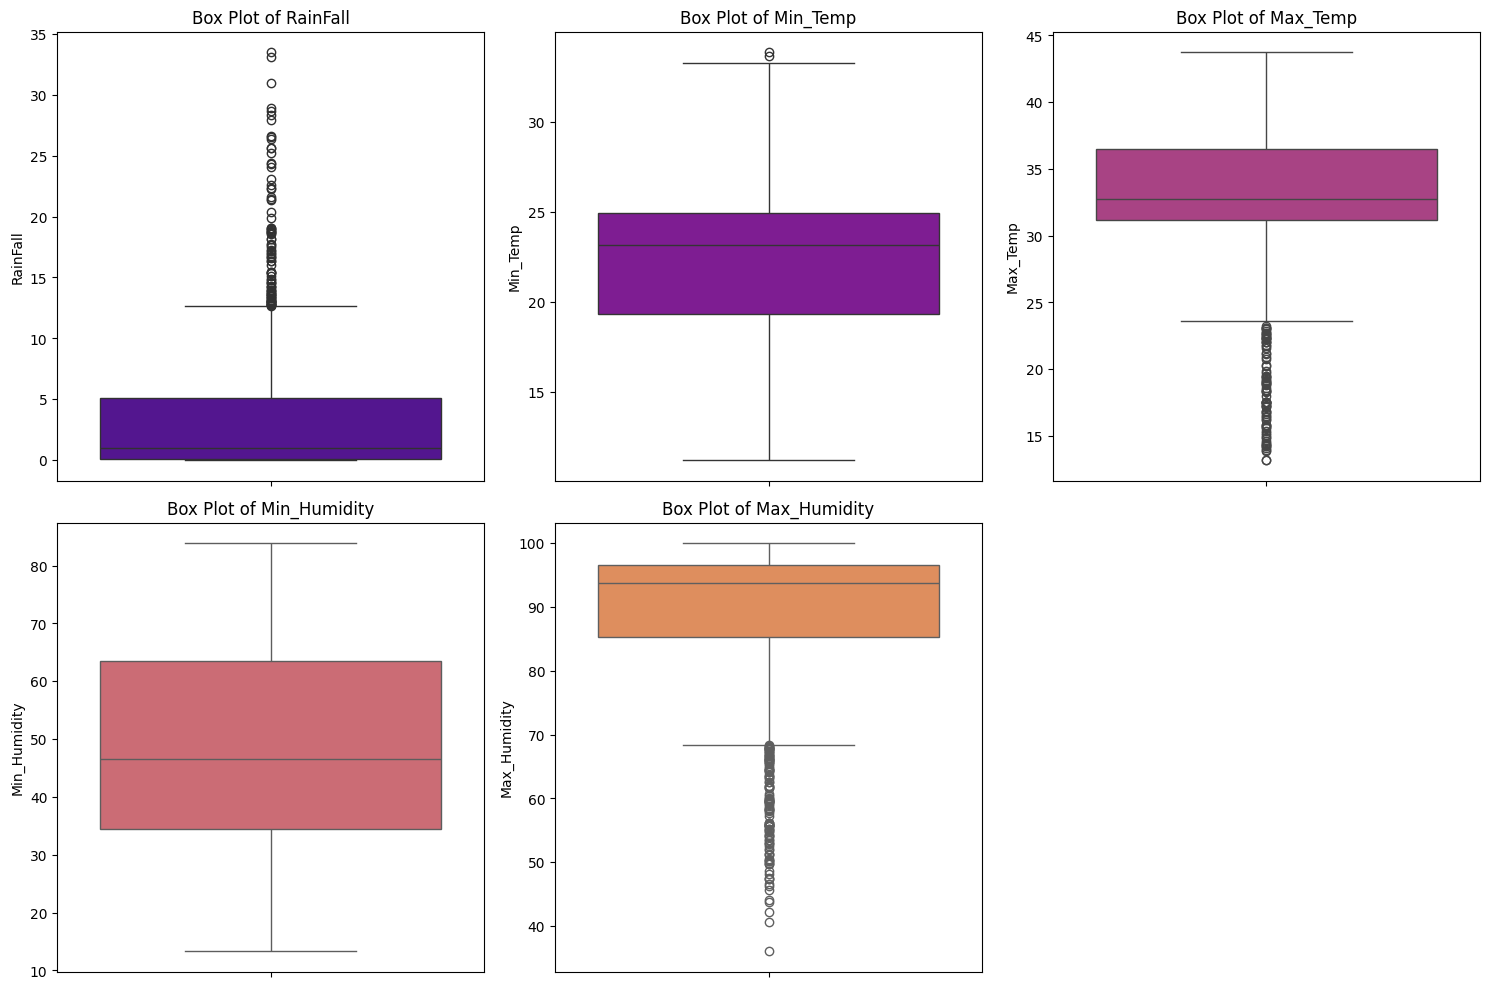

In [9]:
# Box plots to analyze outliers and spread

plt.figure(figsize = (15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y = Weather_DF[col], color = sns.color_palette("plasma")[i])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

**Observation :**

- **Rainfall distribution is highly skewed**
    - The long tail to the right, indicating most months across districts receive very little or no rain.
    - However, box plot confirms there are outlier events with extremely high rainfall.
- **Temperature exhibits a clear range**
    - The `Min_Temp` and `Max_Temp` are relatively centered around the typical seasonal averages.
    - The box plots indicates fewer outliers, might be because temperature extremes are rare but its there.
- **Humidity levels are clustered**
    - The `Min_Humidity` and `Max_Humidity` are concentrated around specific values.
    - But the box plots showing a wide spread of values.

### 1.6 Time Series Analysis (Monthly Trends)

In [10]:
monthly_avg_weather = Weather_DF.groupby('Month')[numerical_cols].mean().reset_index()

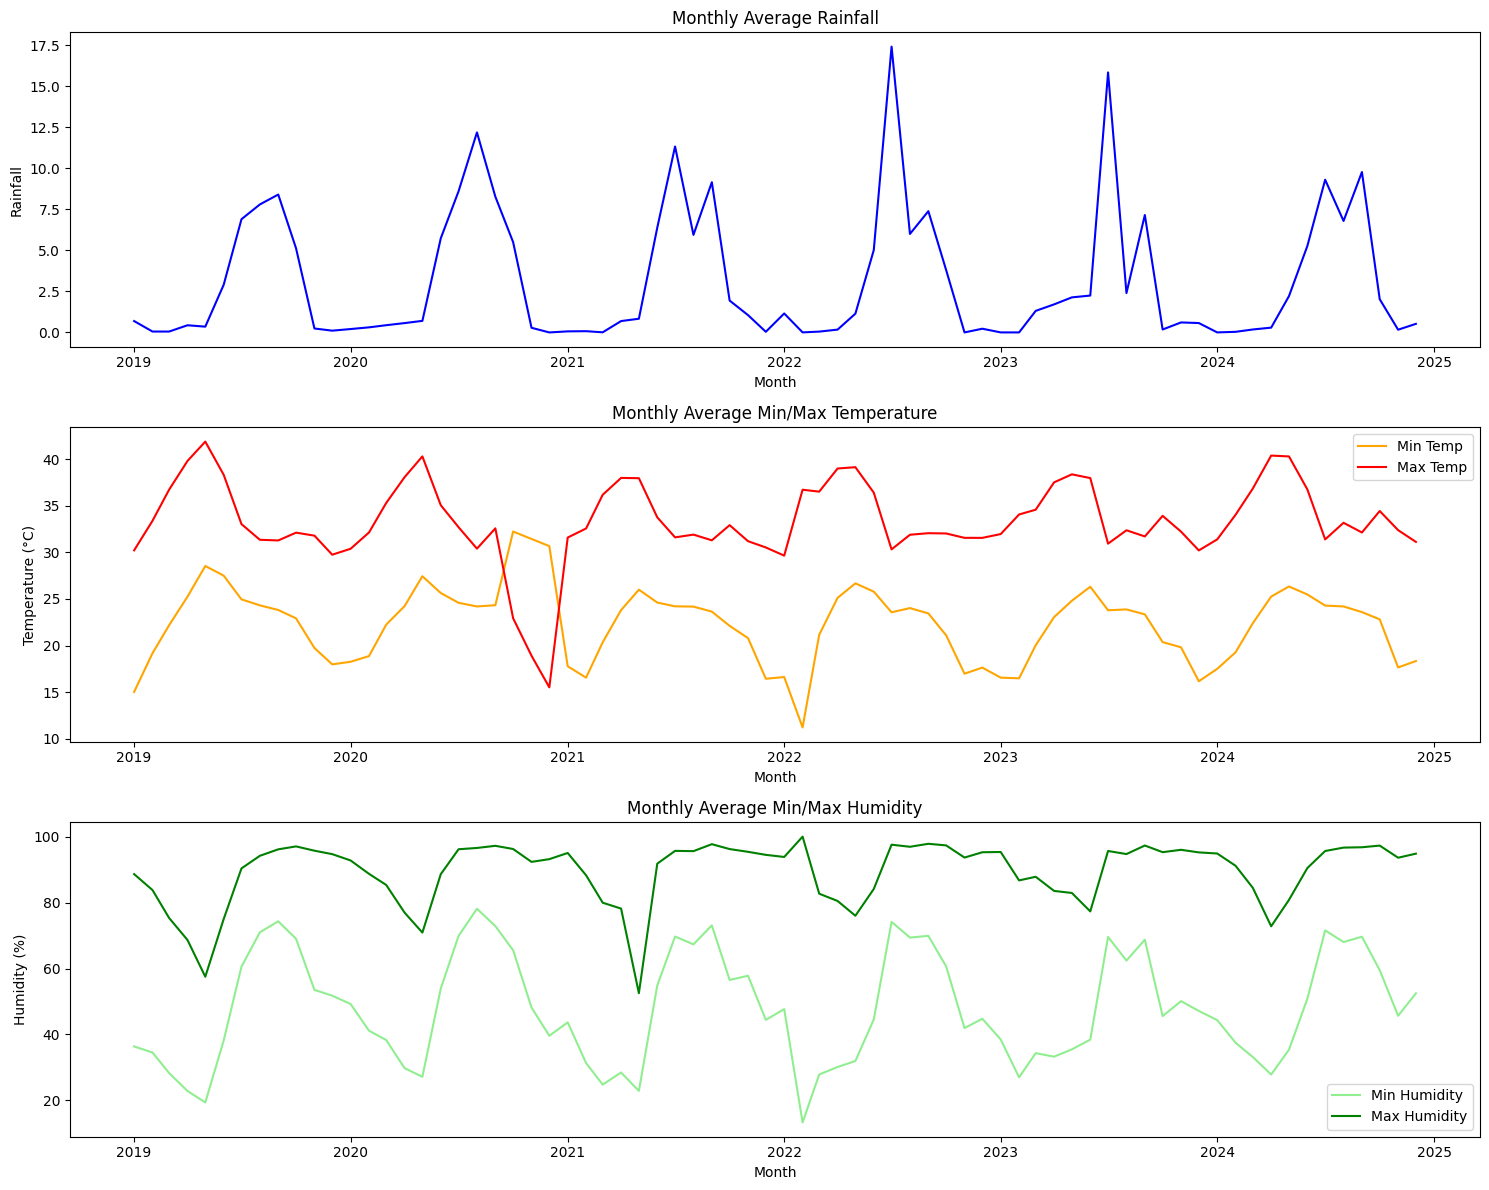

In [11]:
plt.figure(figsize=(15, 12))
plt.subplot(3, 1, 1)
sns.lineplot(data = monthly_avg_weather, x = 'Month', y = 'RainFall', color = 'blue')
plt.title('Monthly Average Rainfall')
plt.ylabel('Rainfall')

plt.subplot(3, 1, 2)
sns.lineplot(data = monthly_avg_weather, x = 'Month', y = 'Min_Temp', label = 'Min Temp', color = 'orange')
sns.lineplot(data = monthly_avg_weather, x = 'Month', y = 'Max_Temp', label = 'Max Temp', color = 'red')
plt.title('Monthly Average Min/Max Temperature')
plt.ylabel('Temperature (°C)')
plt.legend()

plt.subplot(3, 1, 3)
sns.lineplot(data = monthly_avg_weather, x = 'Month', y = 'Min_Humidity', label = 'Min Humidity', color = 'lightgreen')
sns.lineplot(data = monthly_avg_weather, x = 'Month', y = 'Max_Humidity', label = 'Max Humidity', color = 'green')
plt.title('Monthly Average Min/Max Humidity')
plt.xlabel('Month')
plt.ylabel('Humidity (%)')
plt.legend()
plt.tight_layout()
plt.show()

**Observation**

- **Clear seasonal patterns**
    - All three plots shows strong seasonal cycles.
    - Rainfall and humidity peak during the monsoon months.
    - While temperatures peaks in the summer and a trough in the winter.
- **Inverse relationship between temperature and rainfall**
    - The plot for `Min/Max Temp` shows that temperatures drops significantly during high rainfall periods.
    - Confirming the cooling effect of the monsoon season.
- **Humidity is a function of rainfall**
    - The `Min/Max Humidity` plot closely follows the pattern of the `RainFall` plot.
    - Showing humidity levels are directly influenced by the amount of precipitation.

**Reference**
- [What is the relation between humidity and rain?](https://www.quora.com/What-is-the-relation-between-humidity-and-rain)

### 1.7 District-wise Analysis

In [12]:
district_avg_weather = Weather_DF.groupby('District')[numerical_cols].mean().reset_index()

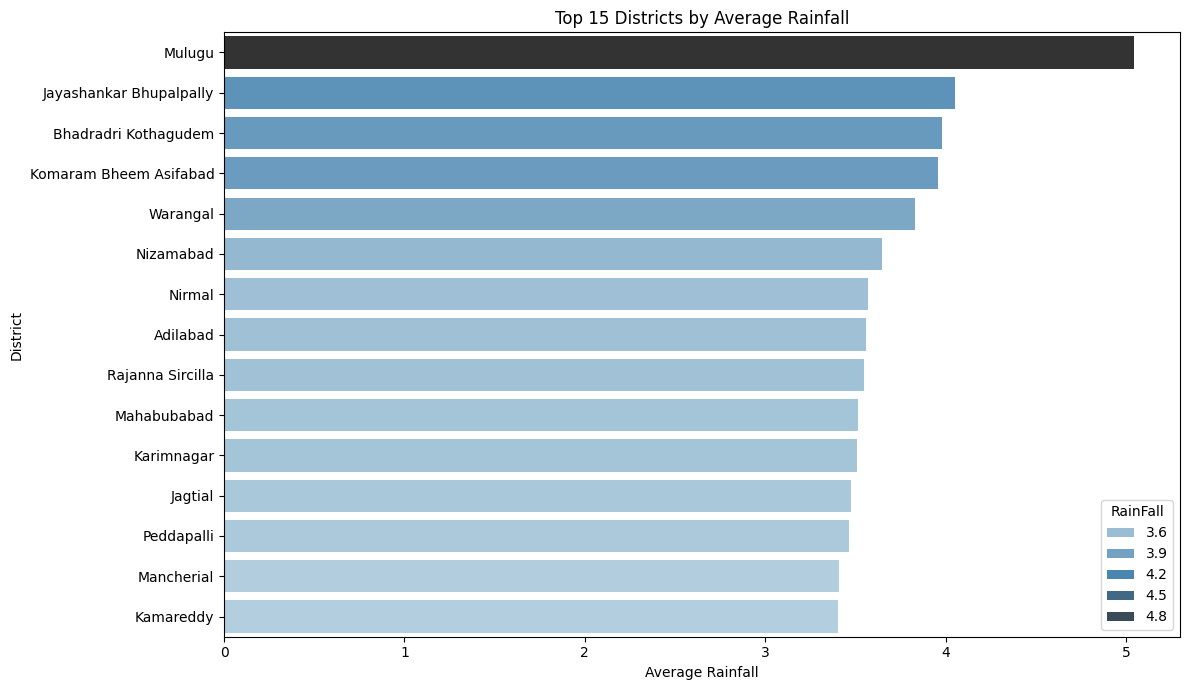

In [13]:
# Sort by rainfall for visualization

district_avg_weather_sorted_rainfall = district_avg_weather.sort_values(by='RainFall', ascending=False).head(15)
plt.figure(figsize=(12, 7))
sns.barplot(data=district_avg_weather_sorted_rainfall, x='RainFall', y='District', hue = 'RainFall', palette='Blues_d')
plt.title('Top 15 Districts by Average Rainfall')
plt.xlabel('Average Rainfall')
plt.ylabel('District')
plt.tight_layout()
plt.show()

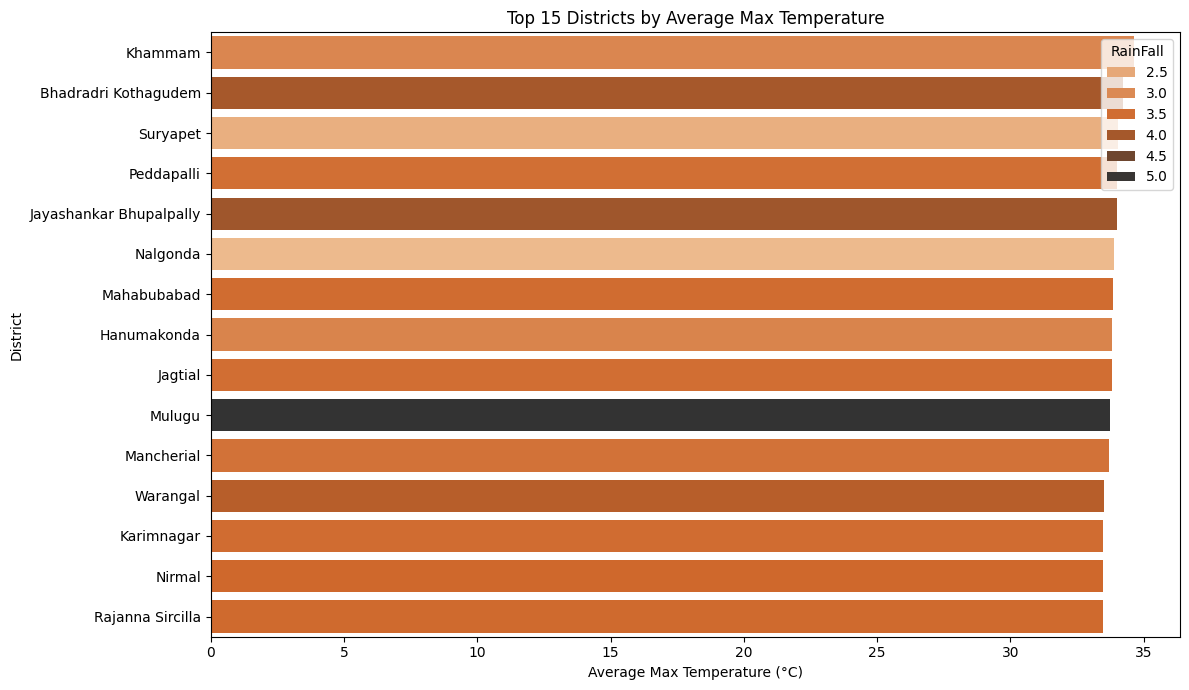

In [14]:
# Sort by Max Temp for visualization
district_avg_weather_sorted_maxtemp = district_avg_weather.sort_values(by='Max_Temp', ascending=False).head(15)
plt.figure(figsize=(12, 7))
sns.barplot(data=district_avg_weather_sorted_maxtemp, x='Max_Temp', y='District', hue = 'RainFall', palette='Oranges_d')
plt.title('Top 15 Districts by Average Max Temperature')
plt.xlabel('Average Max Temperature (°C)')
plt.ylabel('District')
plt.tight_layout()
plt.show()

### 1.8 Correlation Matrix

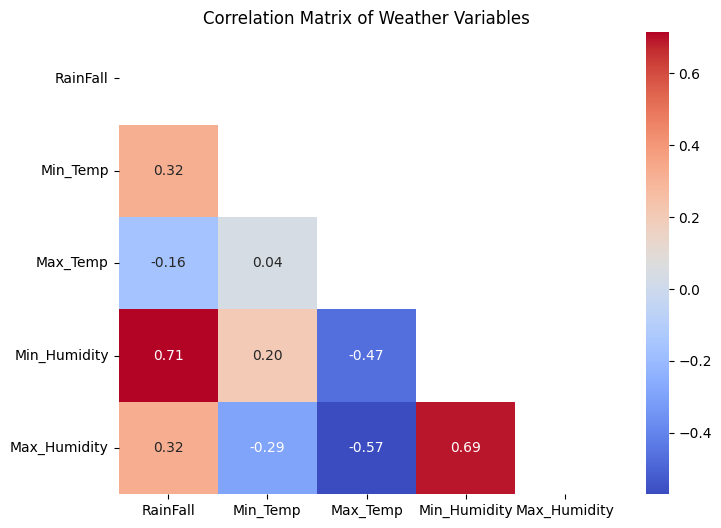

In [15]:
# https://seaborn.pydata.org/examples/many_pairwise_correlations.html

plt.figure(figsize = (8, 6))
corr = Weather_DF[numerical_cols].corr()
mask = np.triu(np.ones_like(corr, dtype = bool))
sns.heatmap(corr, mask=mask, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation Matrix of Weather Variables')
plt.show()

**Observatoin**
- **Weak correlation between temperature variables**
    - It indicates that on a monthly, district-aggregated basis, a month with a high average minimum temperature does not necessarily coincide with a high average maximum temperature.
- **Negative correlation between temperature and rainfall**
    - A negative correlation between `Max_Temp` and `RainFall`, quantifying the cooling effect of rain.
    - This is a key finding for understanding the state's climate dynamics.
- **Positive correlation between rainfall and humidity**
    - There is a strong positive correlation between `RainFall` and `Min_Humidity`, reinforcing the graph in the time-series plots.

## 2. Registration and Stamps Data (Non-Agriculture)

**Column Details**

- `Date` : Data of documents registered
- `Dist_Name` : District Name
- `Documents_Registered_Cnt` : Total Documents Registered Count
- `Documents_Registered_Rev` : Total Documents Registered Revenue
- `Estamps_Challans_Cnt` : E-stamps challans count
- `Estamps_Challans_Rev` : E-stamps challans revenue
- `Slot_Booking_Cnt` : Total online Slot Booking Count

### 2.1 Basic Information

In [16]:
registration_DF = pd.read_csv('Data/processed/Registration_Data_Processed.csv')
print('>>> Registration Data Head\n')
registration_DF.head()

>>> Registration Data Head



,Month,Dist_Name,Documents_Registered_Cnt,Documents_Registered_Rev,Estamps_Challans_Cnt,Estamps_Challans_Rev,Slot_Booking_Cnt
0,2019-01-01,Adilabad,945,12390300,0,0,877
1,2019-01-01,Bhadradri Kothagudem,557,9981040,0,0,38
2,2019-01-01,Hanumakonda,3913,120275730,0,0,859
3,2019-01-01,Hyderabad,5206,643949380,0,0,236
4,2019-01-01,Jagtial,2181,28766596,0,0,904


In [17]:
print('>>> Registration Data Info\n')
registration_DF.info()

>>> Registration Data Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Month                     2290 non-null   object
 1   Dist_Name                 2290 non-null   object
 2   Documents_Registered_Cnt  2290 non-null   int64 
 3   Documents_Registered_Rev  2290 non-null   int64 
 4   Estamps_Challans_Cnt      2290 non-null   int64 
 5   Estamps_Challans_Rev      2290 non-null   int64 
 6   Slot_Booking_Cnt          2290 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 125.4+ KB


In [18]:
print('>>> Registration Data Descriptive statistics\n')
registration_DF.describe()

>>> Registration Data Descriptive statistics



,Documents_Registered_Cnt,Documents_Registered_Rev,Estamps_Challans_Cnt,Estamps_Challans_Rev,Slot_Booking_Cnt
count,2290.000000,2.290000e+03,2290.000000,2.290000e+03,2290.000000
mean,3211.149782,2.217346e+08,2208.357205,1.827154e+08,275.079913
std,4135.171127,5.874795e+08,3775.365279,5.715230e+08,627.762648
min,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000
25%,1091.250000,2.112702e+07,0.000000,0.000000e+00,0.000000
50%,1897.000000,3.866774e+07,1205.000000,2.725687e+07,3.000000
75%,3836.500000,1.014668e+08,2625.750000,7.301116e+07,212.750000
max,33786.000000,5.068863e+09,30526.000000,5.239561e+09,11575.000000


### 2.2 Data Cleaning and Type Correction

In [19]:
# Convert 'Month' to datetime objects for time-series analysis
registration_DF['Month'] = pd.to_datetime(registration_DF['Month'])

### 2.3 Missing Values Check

In [20]:
print('>>> Missing Values in Data\n')
print(registration_DF.isnull().sum())

>>> Missing Values in Data

Month                       0
Dist_Name                   0
Documents_Registered_Cnt    0
Documents_Registered_Rev    0
Estamps_Challans_Cnt        0
Estamps_Challans_Rev        0
Slot_Booking_Cnt            0
dtype: int64


### 2.4 Unique Values and Cardinality

In [21]:
print(f'Unique # Districts in Registration Data :: {registration_DF['Dist_Name'].nunique()}')
print('>>> Top 5 districts by data points')
registration_DF['Dist_Name'].value_counts().head()

Unique # Districts in Registration Data :: 33
>>> Top 5 districts by data points


Dist_Name
Adilabad                71
Bhadradri Kothagudem    71
Hanumakonda             71
Hyderabad               71
Jagtial                 71
Name: count, dtype: int64

### 2.5 Distribution of Numerical Features

In [22]:
numerical_cols = ['Documents_Registered_Cnt', 'Documents_Registered_Rev', 'Estamps_Challans_Cnt',
                  'Estamps_Challans_Rev', 'Slot_Booking_Cnt']

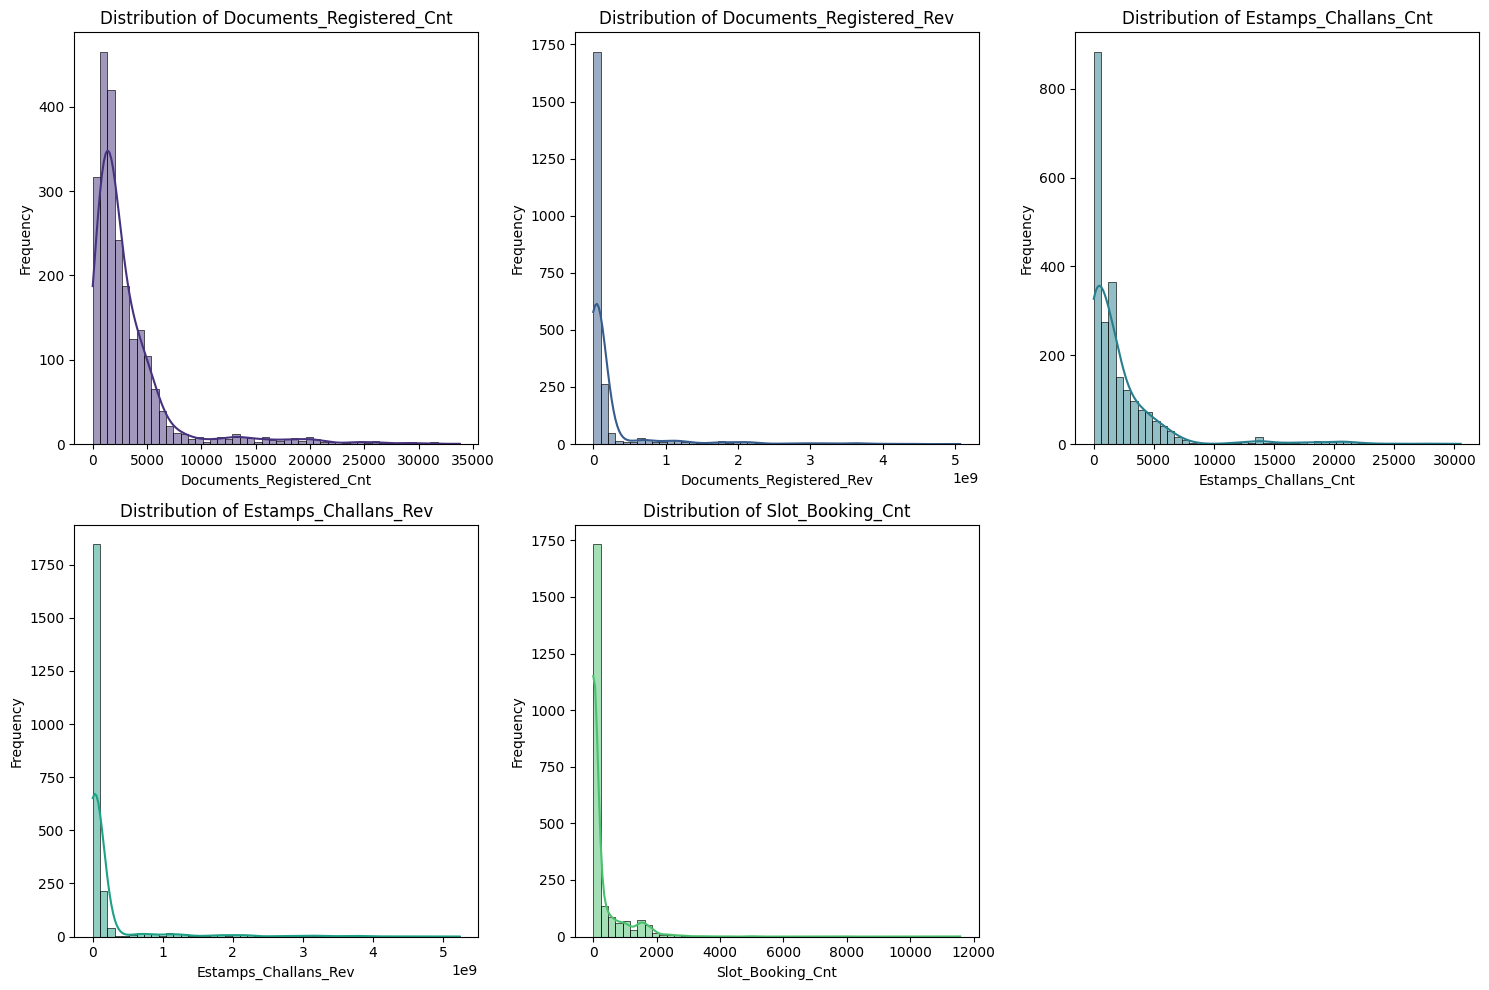

In [23]:
# Distribution Plots

plt.figure(figsize = (15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    if col in numerical_cols:
        sns.histplot(registration_DF[col], kde = True, bins = 50, color = sns.color_palette('viridis')[i])
        plt.xlabel(f'{col}')
    else:
        sns.histplot(reg_df[col], kde = True, bins = 30, color = sns.color_palette("viridis")[i])
        plt.xlabel(col)
    plt.title(f'Distribution of {col}')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

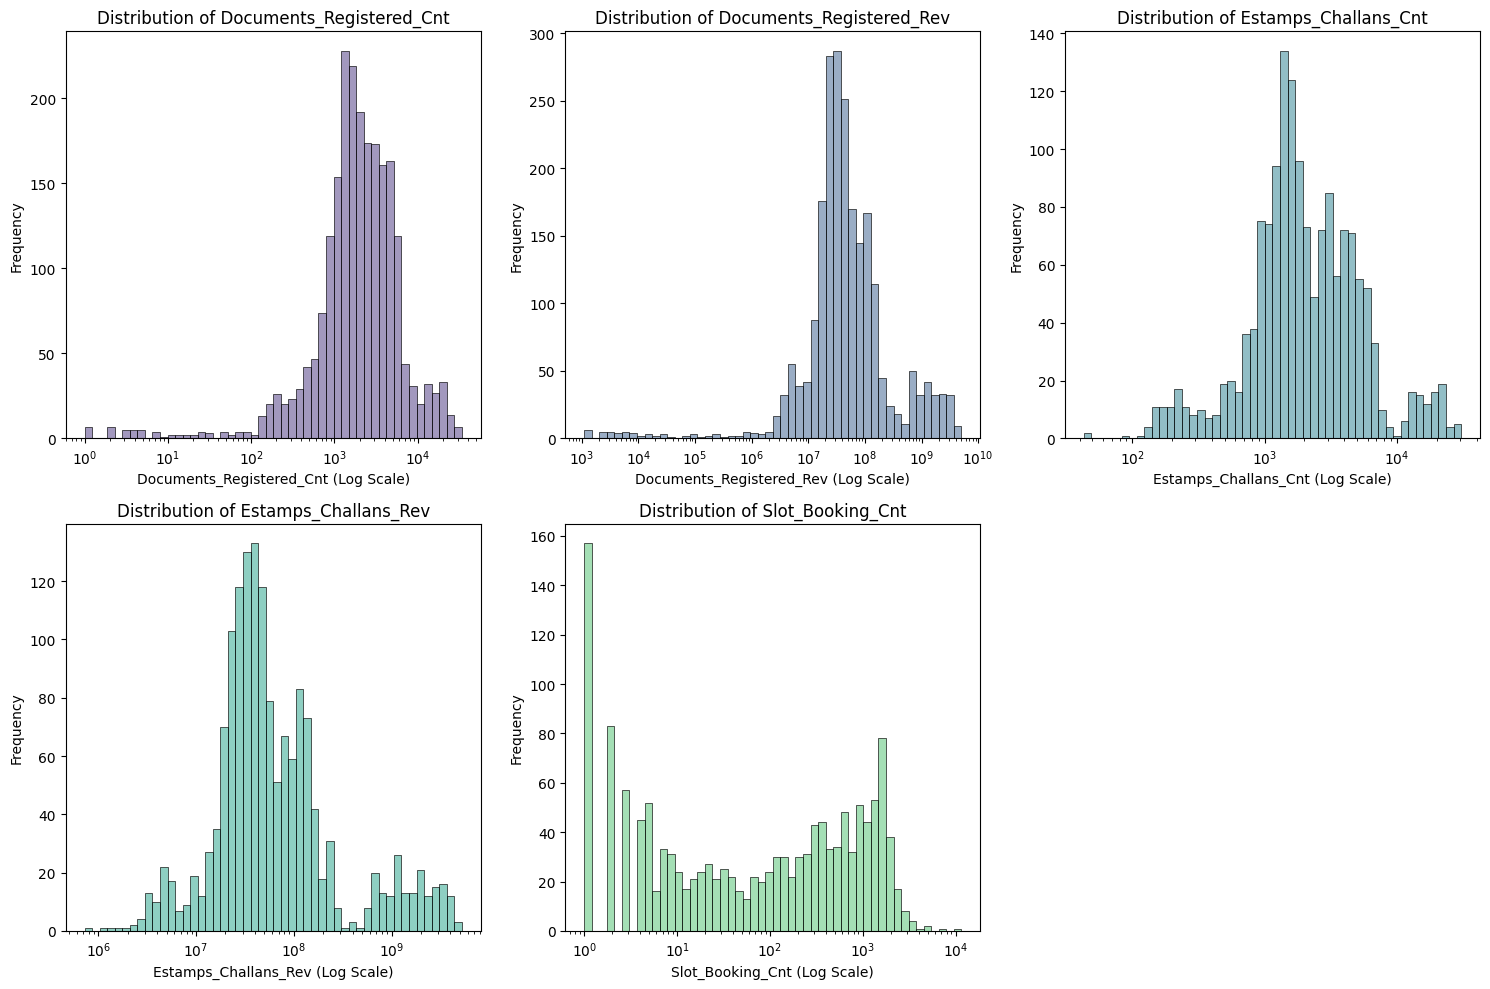

In [24]:
# Highly Skewed Data -> Log-Scaled Distribution Plots 

plt.figure(figsize = (15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    if col in numerical_cols:
        sns.histplot(registration_DF[col], kde = True, bins = 50, color = sns.color_palette('viridis')[i], log_scale = True)
        plt.xlabel(f'{col} (Log Scale)')
    else:
        sns.histplot(reg_df[col], kde = True, bins = 30, color = sns.color_palette("viridis")[i])
        plt.xlabel(col)
    plt.title(f'Distribution of {col}')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

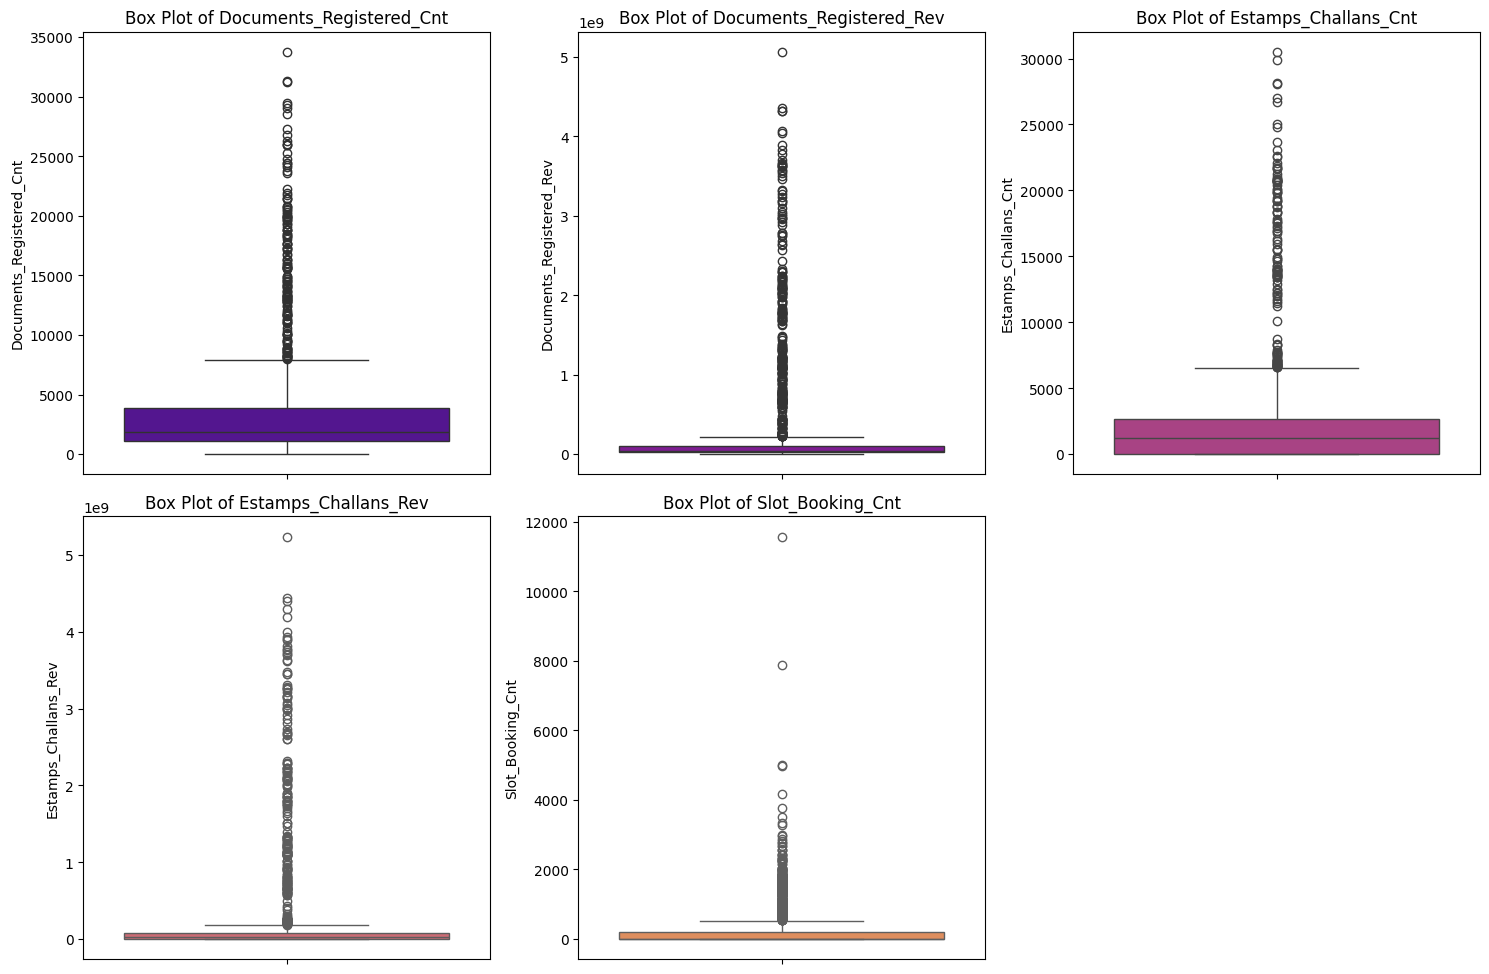

In [25]:
# Box plots to analyze outliers and spread

plt.figure(figsize = (15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y = registration_DF[col], color = sns.color_palette('plasma')[i])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

**Observations :**
- **Heavy Skewness**
    - All key numerical metrics—`Documents_Registered_Cnt`, `Documents_Registered_Rev`, `Estamps_Challans_Cnt`, and `Slot_Booking_Cnt` shows a substantial right-skewed distribution.
    - This indicates most of the data points are concentrated at the lower end, while a few outliers have extremely high values.
- **Outliers decides the Averages**
    - The average values for these metrics will be heavily influenced by a small number of high-performing districts or months.
    - Median would be more robust measure for a "typical" district's activity.

### 2.6 Time Series Analysis (Monthly Trends)

In [26]:
selected_cols = ['Documents_Registered_Cnt', 'Documents_Registered_Rev', 'Estamps_Challans_Cnt',
                 'Estamps_Challans_Rev', 'Slot_Booking_Cnt']
cols_rename = {'Documents_Registered_Cnt' : 'Total_Documents_Registered',
               'Documents_Registered_Rev' : 'Total_Revenue',
               'Estamps_Challans_Cnt' : 'Total_Estamps_Cnt',
               'Estamps_Challans_Rev' : 'Total_Estamps_Rev',
               'Slot_Booking_Cnt' : 'Total_Slot_Bookings'}

monthly_reg_trends = registration_DF.groupby('Month')[selected_cols].agg('sum').\
                     rename(columns = cols_rename).reset_index()

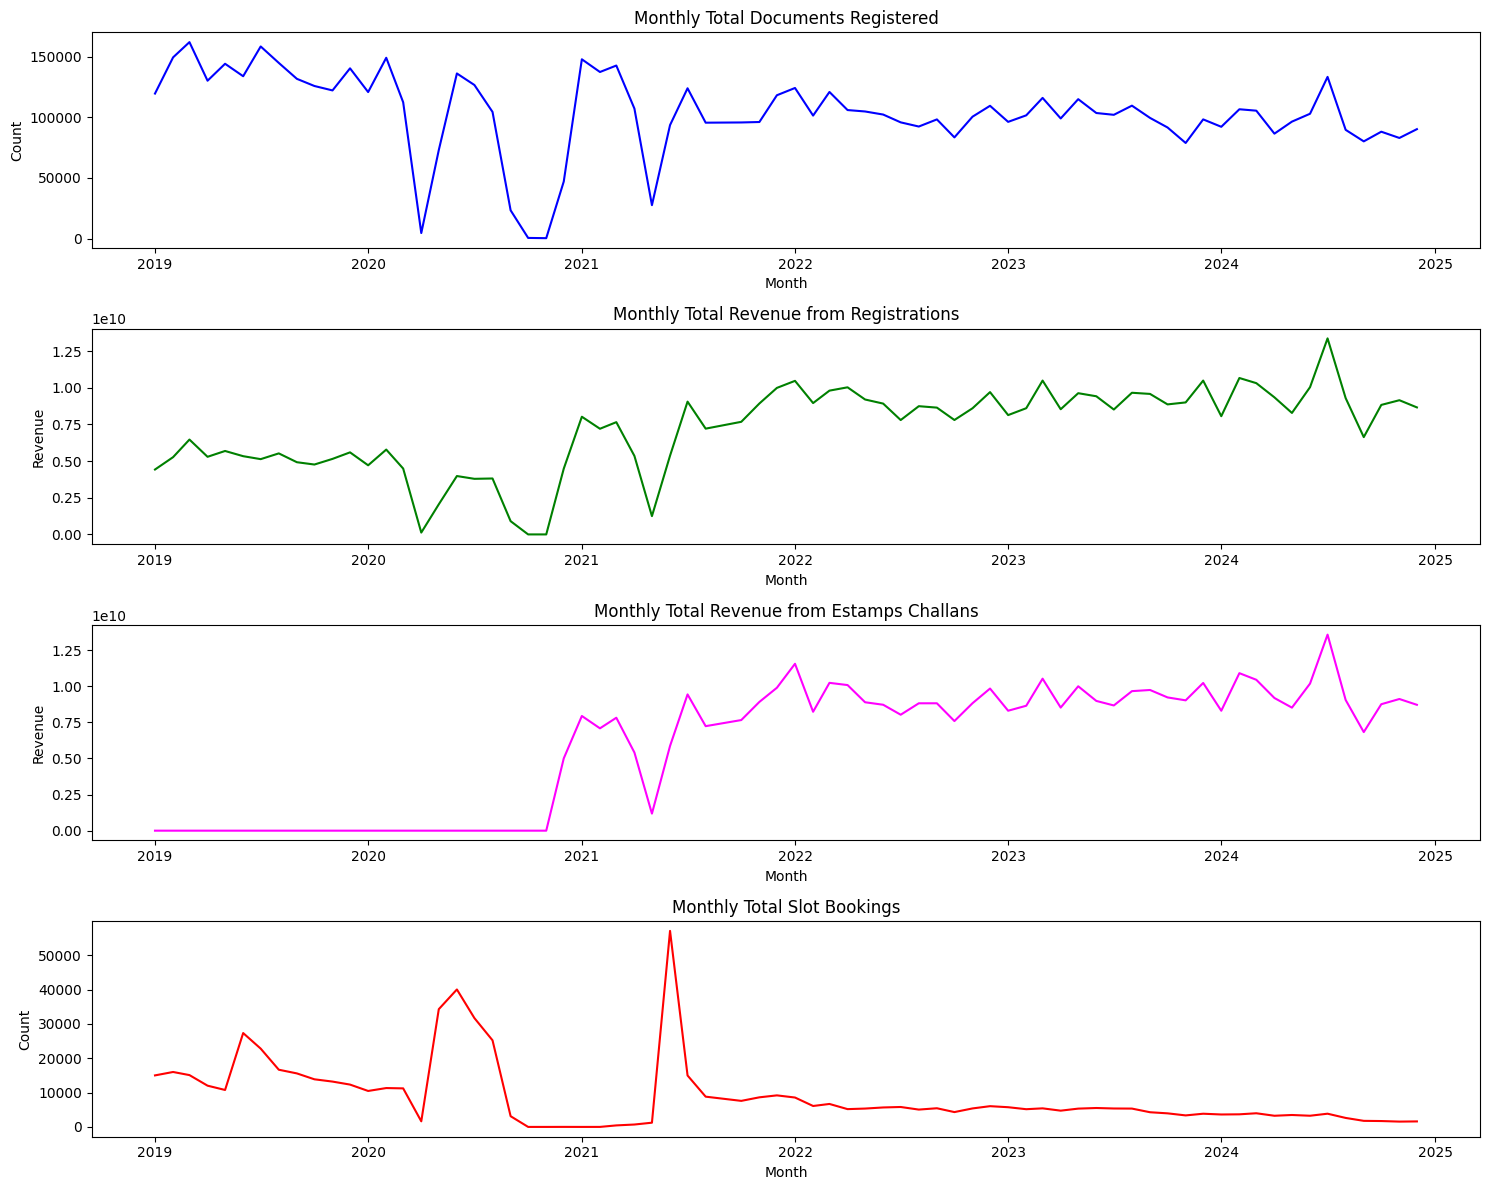

In [27]:
# Registration Data Monthly Trends Analysis

plt.figure(figsize = (15, 12))
plt.subplot(4, 1, 1)
sns.lineplot(monthly_reg_trends, x = 'Month', y = 'Total_Documents_Registered', color = 'blue')
plt.title('Monthly Total Documents Registered')
plt.ylabel('Count')

plt.subplot(4, 1, 2)
sns.lineplot(monthly_reg_trends, x = 'Month', y = 'Total_Revenue', color = 'green')
plt.title('Monthly Total Revenue from Registrations')
plt.ylabel('Revenue')

plt.subplot(4, 1, 3)
sns.lineplot(monthly_reg_trends, x = 'Month', y = 'Total_Estamps_Rev', color = 'fuchsia')
plt.title('Monthly Total Revenue from Estamps Challans')
plt.ylabel('Revenue')
plt.xlabel('Month')

plt.subplot(4, 1, 4)
sns.lineplot(monthly_reg_trends, x = 'Month', y = 'Total_Slot_Bookings', color = 'red')
plt.title('Monthly Total Slot Bookings')
plt.xlabel('Month')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

**Observation :**
- **Revenue is Decoupled from Volume**
    - Revenue is consistently growing, but document count has plateaued, signaling a rise in the value of each transaction.
- **Successful Digital Inclusion**
    - The e-stamp system's late 2020 launch was a big success, becoming a key driver of increased revenue.
- **Pandemic Catalyzed Change**
    - The 2020 economic downturn was followed by a fundamental shift to a digital-first, higher-value market.
- **Slot Bookings Evolved**
    - The booking process is no longer an indicator of market activity, as its became unpredictable.

### 2.7 District-wise Analysis

In [28]:
selected_cols = ['Documents_Registered_Cnt', 'Documents_Registered_Rev', 'Slot_Booking_Cnt']
cols_rename = {'Documents_Registered_Cnt' : 'Overall_Documents_Registered',
               'Documents_Registered_Rev' : 'Overall_Revenue',
               'Slot_Booking_Cnt' : 'Overall_Slot_Bookings'}

district_reg_summary = registration_DF.groupby('Dist_Name')[selected_cols].agg('sum')\
                       .rename(columns = cols_rename).reset_index()

# Converting Documents count to Millions
district_reg_summary.Overall_Documents_Registered = round(district_reg_summary.Overall_Documents_Registered / 1e6, 3)

# Converting Documents count to Billions
district_reg_summary.Overall_Revenue = round(district_reg_summary.Overall_Revenue / 1e9, 3)

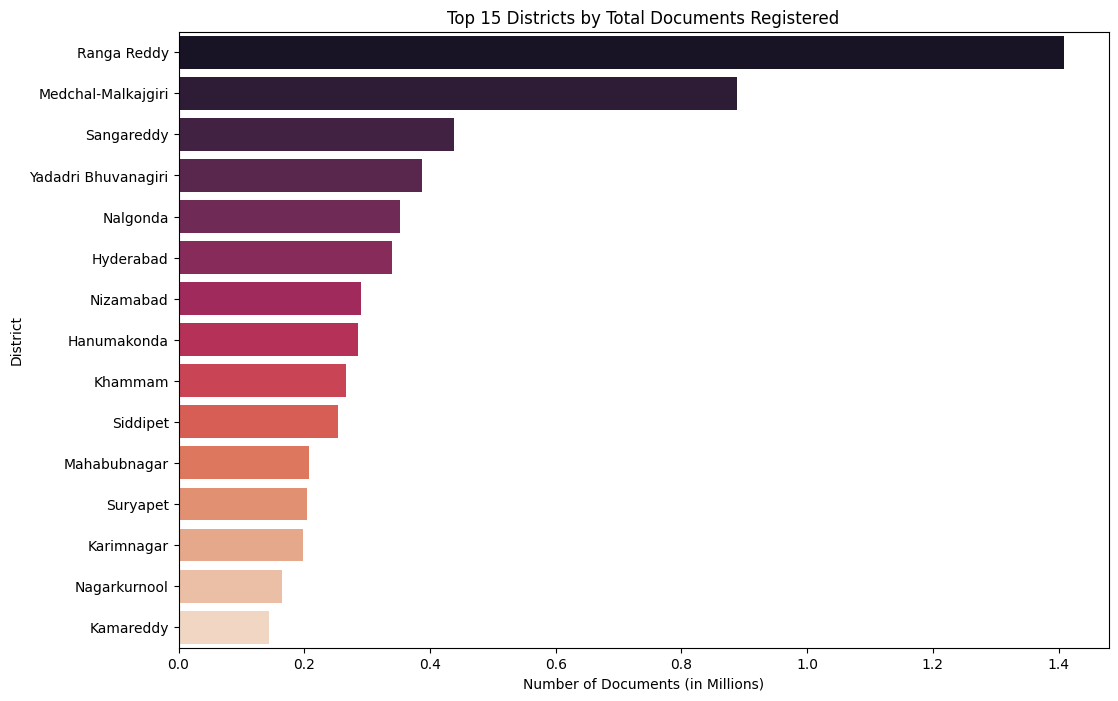

In [29]:
# Top 15 Districts by Documents Registered

district_docs_top = district_reg_summary.sort_values('Overall_Documents_Registered', ascending = False).head(15)

plt.figure(figsize = (12, 8))
sns.barplot(data = district_docs_top, x = 'Overall_Documents_Registered', y = 'Dist_Name', palette = 'rocket')
plt.title('Top 15 Districts by Total Documents Registered')
plt.xlabel('Number of Documents (in Millions)')
plt.ylabel('District')
plt.show()

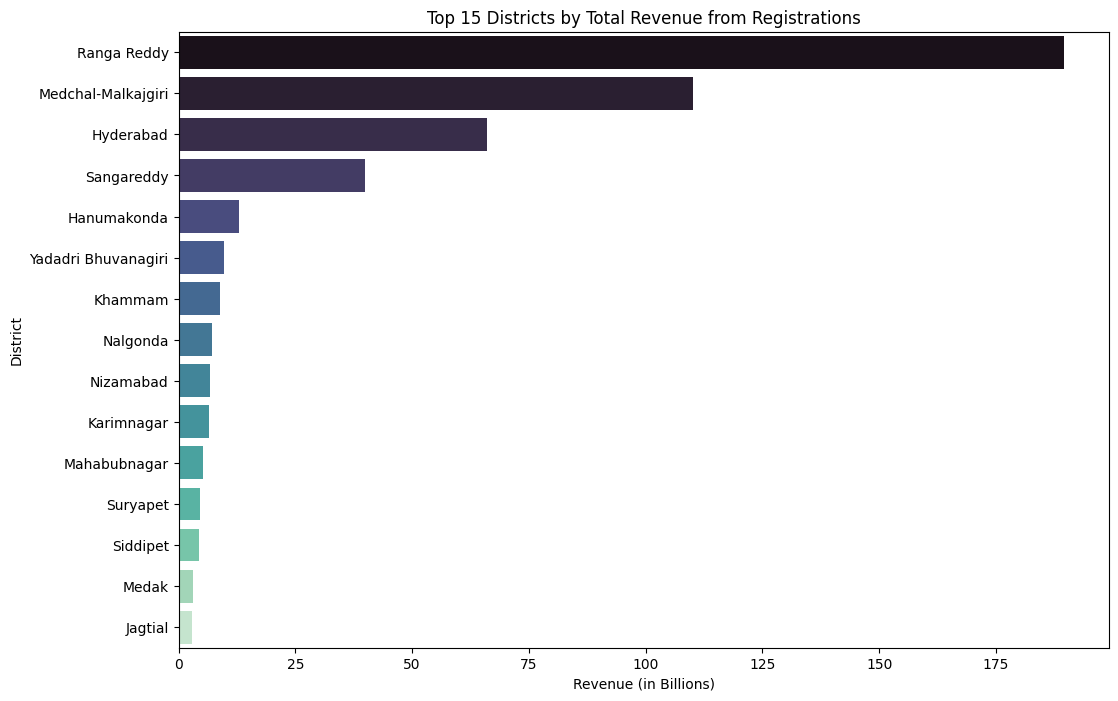

In [30]:
# Top 15 Districts by Revenue

district_revenue_top = district_reg_summary.sort_values('Overall_Revenue', ascending = False).head(15)

plt.figure(figsize = (12, 8))
sns.barplot(district_revenue_top, x = 'Overall_Revenue', y = 'Dist_Name', palette = 'mako')
plt.title('Top 15 Districts by Total Revenue from Registrations')
plt.xlabel('Revenue (in Billions)')
plt.ylabel('District')
plt.show()

**Observations :**

- **Urban Concentration**
    - The both bar plots show a clear activity concentration in a few major districts.
    - This highlights the rapid urbanization and economic development occurring only in specific regions.
- **Revenue vs Volume**
    - Districts with the highest number of registered documents mostly generates the most revenue.